<a href="https://colab.research.google.com/github/AntonyJohny/Innomatics_Research_Labs/blob/main/IN126001202_GenAI/Task_4/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers[torch] datasets accelerate -U

In [ ]:
from datasets import load_dataset

# Loading only a small portion (e.g., 2000 samples) to ensure fast training for the deadline
dataset = load_dataset("imdb")
train_data = dataset['train'].shuffle(seed=42).select(range(2000))
test_data = dataset['test'].shuffle(seed=42).select(range(500))

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

tokenized_train = train_data.map(tokenize_function, batched=True)
tokenized_test = test_data.map(tokenize_function, batched=True)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# Freeze all BERT parameters
for param in model.bert.parameters():
    param.requires_grad = False

print("Backbone frozen. Only training the classifier head.")

In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=1, # Keep it low for quick submission
    weight_decay=0.01,
    # evaluation_strategy="epoch" # Removed to fix TypeError
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

trainer.train()

              precision    recall  f1-score   support

           0       0.53      0.81      0.64       254
           1       0.55      0.25      0.34       246

    accuracy                           0.53       500
   macro avg       0.54      0.53      0.49       500
weighted avg       0.54      0.53      0.49       500



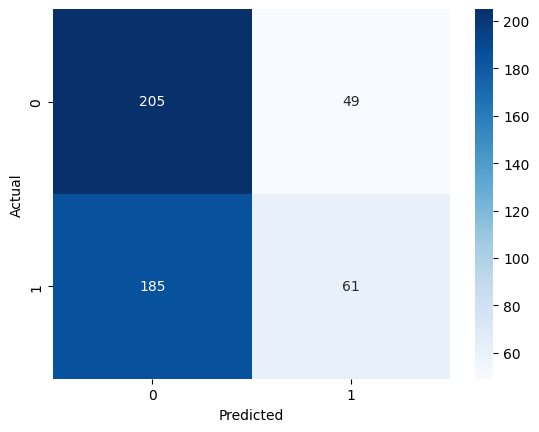

In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
raw_pred, _, _ = trainer.predict(tokenized_test)
y_pred = np.argmax(raw_pred, axis=1)
y_true = tokenized_test["label"]

# Print metrics
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()